# Lab 3: Model-based CF

## Section 1: Revisit Item-to-item (with Surprise)

In [1]:
!pip install scikit-surprise

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.4/154.4 kB 2.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-surprise: filename=scikit_surprise-1.1.4-cp311-cp311-linux_x86_64.whl size=2505185 sha256=d90a049dcfeaf661e69e61d5601f739ba0267e2781151ba49aa1e5d8bf36e0be
  Stored in directory: /root/.cache/pip/wheels/2a/8f/6e/7e2899163e2d85d8266daab4aa1cdabec7a6c56f83c015b5af
Successfully built scikit-surprise


In [2]:
import numpy as np
import pandas as pd
import heapq
from surprise import Dataset, Reader
from surprise import SVD, NMF, KNNBasic
from surprise.similarities import cosine, msd, pearson
from surprise import accuracy
from surprise.model_selection import train_test_split

In [3]:
from urllib.request import urlretrieve
import zipfile, os

In [4]:
# If file exists, skip the download
data_100k_file_path = "movielens/Movielens100K/"
data_100k_file_name = data_100k_file_path + "ml-100k.zip"


# If directory does not exist, create
if not os.path.exists(data_100k_file_path):
    os.makedirs(data_100k_file_path)

if not os.path.exists(data_100k_file_name):
    urlretrieve("http://files.grouplens.org/datasets/movielens/ml-100k.zip", data_100k_file_name)

In [5]:
# unzip and read the u.data file
dataFile = zipfile.ZipFile(data_100k_file_path + "ml-100k.zip")

u_rating_path = dataFile.extract("ml-100k/u.data", path = data_100k_file_path)

In [6]:
columns = ['user_id', 'item_id', 'rating', 'timestamp']
data = pd.read_csv(u_rating_path, sep = '\t', names = columns)

In [7]:
data.head()

,user_id,item_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


#### Surprise has its own data input handle methods, and we need to use reader to read the dataframe and convert to Surprise trainset.

#### Since we are care doing item-based, care about similarity between items, we change the column order

#### Question: Do you remember why we care more about item-based?

In [8]:
reader = Reader(rating_scale = (1, 5) )
item_based_data = Dataset.load_from_df(data[['item_id', 'user_id', 'rating']], reader)

In [9]:
full_trainset = item_based_data.build_full_trainset()

In [10]:
trainSet, testSet = train_test_split(item_based_data, test_size = .2, random_state = 42)

trainSet

#### Different from previous lab, let us first observe the data / ratings

In [11]:
ratingMatrix = pd.pivot_table(data, values = 'rating', index = 'user_id', columns = 'item_id', aggfunc = np.max)
print(ratingMatrix.shape)

(943, 1682)


<ipython-input-11-e25dd4ef6c3b>:1: FutureWarning: The provided callable <function max at 0x7a59639a5760> is currently using DataFrameGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  ratingMatrix = pd.pivot_table(data, values = 'rating', index = 'user_id', columns = 'item_id', aggfunc = np.max)


In [12]:
# Let's transpose the rating matrix and print it out
print(ratingMatrix.T)

user_id  1    2    3    4    5    6    7    8    9    10   ...  934  935  936  \
item_id                                                    ...                  
1        5.0  4.0  NaN  NaN  4.0  4.0  NaN  NaN  NaN  4.0  ...  2.0  3.0  4.0   
2        3.0  NaN  NaN  NaN  3.0  NaN  NaN  NaN  NaN  NaN  ...  4.0  NaN  NaN   
3        4.0  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  ...  NaN  NaN  4.0   
4        3.0  NaN  NaN  NaN  NaN  NaN  5.0  NaN  NaN  4.0  ...  5.0  NaN  NaN   
5        3.0  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  ...  NaN  NaN  NaN   
...      ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...   
1678     NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  ...  NaN  NaN  NaN   
1679     NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  ...  NaN  NaN  NaN   
1680     NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  ...  NaN  NaN  NaN   
1681     NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  ...  NaN  NaN  NaN   
1682     NaN  NaN  NaN  NaN 

We have many missing values! In other words, our data is very sparse, which is usually the case in real-life scenario.

#### Next, we choose two models:

1.   NMF (Non-negative Matrix Factorization): https://surprise.readthedocs.io/en/stable/matrix_factorization.html#surprise.prediction_algorithms.matrix_factorization.NMF
2.   SVD (Singular Vector Decomposition) to predict missing ratings: https://surprise.readthedocs.io/en/stable/matrix_factorization.html#surprise.prediction_algorithms.matrix_factorization.SVD



In [13]:
model_NMF = NMF(n_factors= 15, random_state= 42)
model_SVD = SVD(n_factors= 15, random_state= 42)

model_NMF.fit(trainSet)
model_SVD.fit(trainSet)

#### We will use both models to predict the NaN ratings

In [14]:
predictions_NMF = model_NMF.test(testSet)
predictions_SVD = model_SVD.test(testSet)

In [15]:
# Check the RMSE of the predictions, RMSE is calculated based on the non-NAN value in the testSet
print("NMF model RMSE is {:.3f}".format(accuracy.rmse(predictions_NMF, verbose = False)))
print("SVD model RMSE is {:.3f}".format(accuracy.rmse(predictions_SVD, verbose = False)))

NMF model RMSE is 0.962
SVD model RMSE is 0.935


#### Now we will fit the whole data

In [16]:
model_NMF_fullTrainSet = NMF(n_factors= 15, random_state= 42)

model_NMF_fullTrainSet.sim_options = {'name':'pearson', 'user_based':True}


model_SVD_fullTrainSet = SVD(n_factors= 15, random_state= 42)
model_SVD_fullTrainSet.sim_options = {'name':'pearson', 'user_based':True}

model_NMF_fullTrainSet.fit(full_trainset)
model_SVD_fullTrainSet.fit(full_trainset)

In [17]:
simMatrix_NMF = model_NMF_fullTrainSet.compute_similarities()
simMatrix_SVD = model_SVD_fullTrainSet.compute_similarities()

print('NMF similarity matrix shape: ', simMatrix_NMF.shape)
print('SVD similarity matrix shape: ', simMatrix_SVD.shape)

print('\nPrint the first 5 rows and 5 columns of the NMF similarity matrix:')
print(simMatrix_NMF[0:4, 0:4])

print('\nPrint the first 5 rows and 5 columns of the SVD similarity matrix:')
print(simMatrix_SVD[0:4, 0:4])

NMF similarity matrix shape:  (1682, 1682)
SVD similarity matrix shape:  (1682, 1682)

Print the first 5 rows and 5 columns of the NMF similarity matrix:
[[1.         0.42799905 0.         0.07430376]
 [0.42799905 1.         0.13363062 0.2994642 ]
 [0.         0.13363062 1.         0.78107061]
 [0.07430376 0.2994642  0.78107061 1.        ]]

Print the first 5 rows and 5 columns of the SVD similarity matrix:
[[1.         0.42799905 0.         0.07430376]
 [0.42799905 1.         0.13363062 0.2994642 ]
 [0.         0.13363062 1.         0.78107061]
 [0.07430376 0.2994642  0.78107061 1.        ]]


### Let's find similarity items

In [18]:
# Import the user_id and movie_title mapping data
u_item_path = dataFile.extract("ml-100k/u.item", path = data_100k_file_path)
items = pd.read_csv(u_item_path, sep = '|', encoding = "latin-1", header = None)
items = items.iloc[:,0:2]
items.columns = ['item_id','movie_title']

In [19]:
print('Print part of the item_id and the corresponding movie_title:')
print(items.iloc[0:9, :])

Print part of the item_id and the corresponding movie_title:
   item_id                                        movie_title
0        1                                   Toy Story (1995)
1        2                                   GoldenEye (1995)
2        3                                  Four Rooms (1995)
3        4                                  Get Shorty (1995)
4        5                                     Copycat (1995)
5        6  Shanghai Triad (Yao a yao yao dao waipo qiao) ...
6        7                              Twelve Monkeys (1995)
7        8                                        Babe (1995)
8        9                            Dead Man Walking (1995)


In [20]:
# Select a movie and later we will recommend movies similar to this
print('\n Select a movie that I like, and find its item_id')
print(items[items['movie_title'].str.contains('Star Wars')])


 Select a movie that I like, and find its item_id
    item_id       movie_title
49       50  Star Wars (1977)


In [21]:
# Similarity of this selected movie and the others
sim_selected = simMatrix_NMF[49]
print('\n Similarities based on the selected movie \n', sim_selected)


 Similarities based on the selected movie 
 [ 0.05365553  0.24856031 -0.875      ...  0.          0.
  0.        ]


In [22]:
# Find the indices of the k most similar items
k = 10
k_sim_idx_heap = []
for i in range(len(sim_selected)):
    if i == 49:
        continue
    if len(k_sim_idx_heap) < k:
        heapq.heappush(k_sim_idx_heap, (sim_selected[i], i))
    else:
        if sim_selected[i] > k_sim_idx_heap[0][0]:
            heapq.heappop(k_sim_idx_heap)
            heapq.heappush(k_sim_idx_heap, (sim_selected[i], i))

print(k_sim_idx_heap)

[(1.0, 343), (1.0, 398), (1.0, 448), (1.0, 626), (1.0, 1085), (1.0, 1153), (1.0, 1160), (1.0, 1135), (1.0, 788), (1.0, 1308)]


In [23]:
# print out the corresponding movie_title
# since it is min heap, when printing we print from the last item to the first item
print('\n The recommemed movies are:')
for i in range(len(k_sim_idx_heap)-1, -1, -1):
    idx = k_sim_idx_heap[i][1]
    print(items.iloc[idx, 1])


 The recommemed movies are:
Very Natural Thing, A (1974)
Swimming with Sharks (1995)
Ghosts of Mississippi (1996)
Palookaville (1996)
Alphaville (1965)
It's My Party (1995)
Robin Hood: Prince of Thieves (1991)
Star Trek: The Motion Picture (1979)
Three Musketeers, The (1993)
Apostle, The (1997)


## Section 2: Build an MF (Matrix Factorization) (with PyTorch and Surprise)

In [24]:
!pip install scikit-surprise

In [25]:
from surprise import Dataset
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.utils import shuffle

### We first need to define a data loader

In [26]:
class Loader():
    current = 0

    def __init__(self, x, y, batch_size=2048, is_shuffle=True):
        from sklearn.utils import shuffle
        self.shuffle = shuffle
        self.x = x
        self.y = y
        self.batch_size = batch_size
        self.batches = range(0, len(self.y), batch_size)

        # If is_shuffle, we re-shuffle on every epoch
        if is_shuffle:
            self.x, self.y = shuffle(self.x, self.y)

    def __iter__(self):
        # Reset and return a new iterator
        self.x, self.y = shuffle(self.x, self.y,random_state=0)
        self.current = 0
        return self

    def __len__(self):
        # Return the number of batches
        return int(len(self.x)/self.batch_size)

    def __next__(self):
        n = self.batch_size

        if self.current + n >= len(self.y):
            raise StopIteration

        i = self.current
        xs = torch.from_numpy(self.x[i:i + n])
        ys = torch.from_numpy(self.y[i:i + n])

        self.current += n

        return (xs, ys)

### Let us build a Matrix Factorization (MF) model using PyTorch

In [27]:
class MF(nn.Module):

    def __init__(self, n_user, n_item, k=18, c_vector=1.0, c_bias=1.0):
        super(MF, self).__init__()
        self.k = k
        self.n_user = n_user
        self.n_item = n_item
        self.c_bias = c_bias
        self.c_vector = c_vector

        self.user = nn.Embedding(n_user, 1)
        self.item = nn.Embedding(n_item, 1)

        # We add new terms here:
        self.bias_user = nn.Embedding(n_user, 1)
        self.bias_item = nn.Embedding(n_item, 1)

        self.bias = nn.Parameter(torch.ones(1))

    def forward(self, train_x):
        user_id = train_x[:, 0]
        item_id = train_x[:, 1]

        vector_user = self.user(user_id)
        vector_item = self.item(item_id)

        # Pull out biases
        bias_user = self.bias_user(user_id).squeeze()
        bias_item = self.bias_item(item_id).squeeze()

        biases = self.bias + bias_user + bias_item

        ui_interaction = torch.sum(vector_user * vector_item, dim=1)

        # Add bias prediction to the interaction prediction
        prediction = ui_interaction + biases
        return prediction

    def loss(self, prediction, target):

        def l2_regularize(array):
            loss = torch.sum(array**2)
            return loss

        loss_mse = F.mse_loss(prediction, target.squeeze())

        # Add new regularization to the biases
        prior_bias_user =  l2_regularize(self.bias_user.weight) * self.c_bias
        prior_bias_item = l2_regularize(self.bias_item.weight) * self.c_bias

        prior_user =  l2_regularize(self.user.weight) * self.c_vector
        prior_item = l2_regularize(self.item.weight) * self.c_vector

        total = loss_mse + prior_bias_user + prior_bias_item + prior_user + prior_item
        return total

### Finally, we define the main() function

In [28]:
def main():
    # Get data
    data = Dataset.load_builtin('ml-1m')
    trainset = data.build_full_trainset()
    uir = np.array([x for x in trainset.all_ratings()])

    train_x = test_x = uir[:,:2].astype(np.int64)
    train_y = test_y = uir[:,2].astype(np.float32)

    # Define parameters
    lr = 1e-1 # learning rate
    k = 10  # embedding size or latent dimension
    c_bias = 1e-6
    c_vector = 1e-6
    batch_size = 2048

    model = MF(trainset.n_users, trainset.n_items, k=k, c_bias=c_bias, c_vector=c_vector)

    optimizer = torch.optim.Adam(model.parameters(), lr = lr)
    dataloader = Loader(train_x, train_y, batch_size=batch_size)

    itr = 0
    for batch in dataloader:

        itr += 1

        prediction = model(batch[0])
        loss = model.loss(prediction,batch[1])
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        print(f"iteration: {itr}. training loss: {loss}")

    torch.save(model.state_dict(), "./recommendation_model_pytorch.pkl")

if __name__=='__main__':
    main()

Dataset ml-1m could not be found. Do you want to download it? [Y/n] Y
Trying to download dataset from https://files.grouplens.org/datasets/movielens/ml-1m.zip...
Done! Dataset ml-1m has been saved to /root/.surprise_data/ml-1m
iteration: 1. training loss: 10.680660247802734
iteration: 2. training loss: 9.423236846923828
iteration: 3. training loss: 8.537819862365723
iteration: 4. training loss: 6.944299697875977
iteration: 5. training loss: 6.359341621398926
iteration: 6. training loss: 5.7918381690979
iteration: 7. training loss: 4.7025675773620605
iteration: 8. training loss: 4.230647563934326
iteration: 9. training loss: 3.7699384689331055
iteration: 10. training loss: 3.6126654148101807
iteration: 11. training loss: 3.2404098510742188
iteration: 12. training loss: 2.7960140705108643
iteration: 13. training loss: 2.5010485649108887
iteration: 14. training loss: 2.676726818084717
iteration: 15. training loss: 2.4936001300811768
iteration: 16. training loss: 2.3426806926727295
iterati

### Now we're ready to do inference

For inference, we will use most of the code from before (especially the model definition).

In [29]:
from surprise import Dataset
import numpy as np
import torch
import torch.nn as nn
import pandas as pd
import pprint

In [30]:
# This function aims to get the top-N recommendations

def get_top_n(model, testset, trainset, uid_input, movies_df, n=10):

    preds = []
    try:
        uid_input = int(trainset.to_inner_uid(uid_input))
    except KeyError:
        return preds

    # We first map the predictions to each user.
    for uid, iid, _ in testset:
        try:
            uid_internal = int(trainset.to_inner_uid(uid))
        except KeyError:
            continue

        if uid_internal == uid_input:
            try:
                iid_internal = int(trainset.to_inner_iid(iid))
                movie_name = movies_df.loc[int(iid), 'name']
                preds.append((iid, movie_name, float(model(torch.tensor([[uid_input, iid_internal]])))))
            except KeyError:
                pass

    # Then, we sort the predictions for each user and retrieve the k highest ones (i.e., top-K recommendations)
    if preds is not None:
        preds.sort(key= lambda x: x[1], reverse=True)
        if len(preds) > n:
            preds = preds[:n]
    return preds

In [31]:
# This function aims to get previously seen items (i.e., items that user has already seen in the past)

def get_previously_seen(trainset, uid, movies_df):
    seen = []
    for (iid, _) in trainset.ur[int(uid)]:
        try:
            seen.append(movies_df.loc[int(iid), 'name'])
        except KeyError:
            pass
        if len(seen) > 10:
            break
    return seen

In [32]:
def main():
    data = Dataset.load_builtin('ml-1m')

    import os
    files_dir = os.path.expanduser("/root/.surprise_data/ml-1m/ml-1m/")

    movies_df = pd.read_csv(files_dir + 'movies.dat', sep='::', header=None, engine='python',encoding='latin-1')
    movies_df.columns = ['iid','name','genre']
    movies_df.set_index('iid',inplace=True)

    trainset = data.build_full_trainset()
    testset = trainset.build_anti_testset()

    k = 10 # embedding size or latent dimension
    c_bias = 1e-6
    c_vector = 1e-6

    model = MF(trainset.n_users, trainset.n_items, k=k, c_bias=c_bias, c_vector=c_vector)
    model.load_state_dict(torch.load('./recommendation_model_pytorch.pkl'))
    model.eval()

    # Let us print the recommended items for some sample users
    sample_users = list(set([x[0] for x in testset]))[:4]

    for uid in sample_users:

        print('User:',uid)
        print('\n')

        print('\tSeen:')
        seen = get_previously_seen(trainset, uid, movies_df)
        pprint.pprint(seen)
        print('\n')

        print('\tRecommendations:')
        recommended = get_top_n(model, testset, trainset, uid, movies_df, n=10)
        pprint.pprint([x[1] for x in recommended])
        print('\n')



if __name__=="__main__":
    main()

<ipython-input-32-90090620109a>:19: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('./recommendation_model_pytorch.pkl'))


User: 126


	Seen:
['Playing by Heart (1998)',
 'Postino, Il (The Postman) (1994)',
 'East of Eden (1955)',
 '24 7: Twenty Four Seven (1997)',
 'Forget Paris (1995)',
 'Paris, France (1993)',
 'At First Sight (1999)',
 'Intimate Relations (1996)',
 'Kika (1993)',
 'Hate (Haine, La) (1995)',
 'Farmer & Chase (1995)']


	Recommendations:
['eXistenZ (1999)',
 'Zeus and Roxanne (1997)',
 'Zero Kelvin (Kjærlighetens kjøtere) (1995)',
 'Zero Effect (1998)',
 'Zed & Two Noughts, A (1985)',
 'Zachariah (1971)',
 'Your Friends and Neighbors (1998)',
 'Young and Innocent (1937)',
 'Young Sherlock Holmes (1985)',
 "Young Poisoner's Handbook, The (1995)"]


User: 1112


	Seen:
['Right Stuff, The (1983)',
 'French Kiss (1995)',
 'Forget Paris (1995)',
 'Paris, France (1993)',
 'Beans of Egypt, Maine, The (1994)',
 'Hideaway (1995)',
 'Nadja (1994)',
 'Sleepover (1995)',
 'Wings of Courage (1995)',
 'Hate (Haine, La) (1995)',
 'Farmer & Chase (1995)']


	Recommendations:
['eXistenZ (1999)',
 'Zeus a

## Section 3: Implicit feedback recommender (with LightFM)

### Implicit feedback

For some time, the recommender system literature focused on explicit feedback: the Netflix prize focused on accurately reproducing the ratings users have given to movies they watched.

Focusing on ratings in this way ignored the importance of taking into account which movies the users chose to watch in the first place, and treating the absence of ratings as absence of information.

But the things that we don't have ratings for aren't unknowns: we know the user didn't pick them. This reflects a user's conscious choice, and is a good source of information on what she thinks she might like.

This sort of phenomenon is described as data which is missing-not-at-random in the literature: the ratings that are missing are more likely to be negative precisely because the user chooses which items to rate. When choosing a restaurant, you only go to places which you think you'll enjoy, and never go to places that you think you'll hate. What this leads to is that you're only going to be submitting ratings for things which, a priori, you expected to like; the things that you expect you will not like you will never rate.

This observation has led to the development of models that are suitable for implicit feedback. LightFM implements two that have proven particular successful:

- BPR: Bayesian Personalised Ranking pairwise loss [1]. Maximises the prediction difference between a positive example and a randomly chosen negative example. Useful when only positive interactions are present and optimising ROC AUC is desired.
- WARP: Weighted Approximate-Rank Pairwise loss [2]. Maximises the rank of positive examples by repeatedly sampling negative examples until rank violating one is found. Useful when only positive interactions are present and optimising the top of the recommendation list (precision@k) is desired.

This example shows how to estimate these models on the Movielens dataset.

[1] Rendle, Steffen, et al. "BPR: Bayesian personalized ranking from implicit feedback." Proceedings of the Twenty-Fifth Conference on Uncertainty in Artificial Intelligence. AUAI Press, 2009.

[2] Weston, Jason, Samy Bengio, and Nicolas Usunier. "Wsabie: Scaling up to large vocabulary image annotation." IJCAI. Vol. 11. 2011.

### Getting the data

The first step is to get the [Movielens100K data](http://grouplens.org/datasets/movielens/100k/). In preivous labs, we have used this data before by downloading and preprocessing the data.

In this lab, fortunately, this is one of the functions provided by LightFM itself.

In [33]:
!pip install lightfm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.4/316.4 kB 5.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lightfm: filename=lightfm-1.17-cp311-cp311-linux_x86_64.whl size=825336 sha256=3ebeae57e1218845613f5d96a0e3e272e02486368017152afceeaba22915f806
  Stored in directory: /root/.cache/pip/wheels/b9/0d/8a/0729d2e6e3ca2a898ba55201f905da7db3f838a33df5b3fcdd
Successfully built lightfm


In [34]:
import numpy as np

from lightfm.datasets import fetch_movielens

movielens = fetch_movielens()

#### This gives us a dictionary with the following fields:

In [35]:
for key, value in movielens.items():
    print(key, type(value), value.shape)

train <class 'scipy.sparse._coo.coo_matrix'> (943, 1682)
test <class 'scipy.sparse._coo.coo_matrix'> (943, 1682)
item_features <class 'scipy.sparse._csr.csr_matrix'> (1682, 1682)
item_feature_labels <class 'numpy.ndarray'> (1682,)
item_labels <class 'numpy.ndarray'> (1682,)


In [36]:
train = movielens['train']
test = movielens['test']

#### The `train` and `test` elements are the most important: they contain the raw rating data, split into a train and a test set. Each row represents a user, and each column an item. Entries are ratings from 1 to 5.

### Fitting models

#### Now let's train a BPR model and look at its accuracy.

#### We'll use two metrics of accuracy: precision@k and ROC AUC. Both are ranking metrics: to compute them, we'll be constructing recommendation lists for all of our users, and checking the ranking of known positive movies. For precision at k we'll be looking at whether they are within the first k results on the list; for AUC, we'll be calculating the probability that any known positive is higher on the list than a random negative example.

In [37]:
from lightfm import LightFM
from lightfm.evaluation import precision_at_k
from lightfm.evaluation import auc_score

model = LightFM(learning_rate=0.05, loss='bpr')
model.fit(train, epochs=10)

train_precision = precision_at_k(model, train, k=10).mean()
test_precision = precision_at_k(model, test, k=10).mean()

train_auc = auc_score(model, train).mean()
test_auc = auc_score(model, test).mean()

print('Precision: train %.2f, test %.2f.' % (train_precision, test_precision))
print('AUC: train %.2f, test %.2f.' % (train_auc, test_auc))

Precision: train 0.58, test 0.10.
AUC: train 0.90, test 0.86.


#### The WARP model, on the other hand, optimises for precision@k---we should expect its performance to be better on precision.

In [38]:
model = LightFM(learning_rate=0.05, loss='warp')

model.fit_partial(train, epochs=10)

train_precision = precision_at_k(model, train, k=10).mean()
test_precision = precision_at_k(model, test, k=10).mean()

train_auc = auc_score(model, train).mean()
test_auc = auc_score(model, test).mean()

print('Precision: train %.2f, test %.2f.' % (train_precision, test_precision))
print('AUC: train %.2f, test %.2f.' % (train_auc, test_auc))

Precision: train 0.60, test 0.11.
AUC: train 0.93, test 0.90.


#### And that is exactly what we see: we get slightly higher precision@10 (but the AUC metric is also improved).

## Section 4: Learning-to-rank using the WARP loss

LightFM is probably the only recommender package implementing the WARP (Weighted Approximate-Rank Pairwise) loss for implicit feedback learning-to-rank. Generally, it perfoms better than the more popular BPR (Bayesian Personalised Ranking) loss --- often by a large margin.

It was originally applied to image annotations in the Weston et al. [WSABIE paper](http://www.thespermwhale.com/jaseweston/papers/wsabie-ijcai.pdf), but has been extended to apply to recommendation settings in the [2013 k-order statistic loss paper](http://www.ee.columbia.edu/~ronw/pubs/recsys2013-kaos.pdf) in the form of the k-OS WARP loss, also implemented in LightFM.

Like the BPR model, WARP deals with (user, positive item, negative item) triplets. Unlike BPR, the negative items in the triplet are not chosen by random sampling: they are chosen from among those negative items which would violate the desired item ranking given the state of the model. This approximates a form of active learning where the model selects those triplets that it cannot currently rank correctly.

This procedure yields roughly the following algorithm:

1. For a given (user, positive item pair), sample a negative item at random from all the remaining items. Compute predictions for both items; if the negative item's prediction exceeds that of the positive item plus a margin, perform a gradient update to rank the positive item higher and the negative item lower. If there is no rank violation, continue sampling negative items until a violation is found.
2. If you found a violating negative example at the first try, make a large gradient update: this indicates that a lot of negative items are ranked higher than positives items given the current state of the model, and the model must be updated by a large amount. If it took a lot of sampling to find a violating example, perform a small update: the model is likely close to the optimum and should be updated at a low rate.

You can search for WARP loss for implicit feedback recommendation for more details

Having covered the theory, the rest of this example looks at the practical implications of using WARP in LightFM.

In [39]:
import time

import numpy as np

%matplotlib inline

import matplotlib
import numpy as np
import matplotlib.pyplot as plt

from lightfm import LightFM
from lightfm.datasets import fetch_movielens
from lightfm.evaluation import auc_score

movielens = fetch_movielens()

train, test = movielens['train'], movielens['test']

### Accuracy

#### The first interesting experiment is to compare the accuracy between the WARP and BPR losses. Let's fit two models with equivalent hyperparameters and compare their accuracy across epochs. Whilst we're fitting them, let's also measure how much time each epoch takes.

In [40]:
alpha = 1e-05
epochs = 70
num_components = 32

warp_model = LightFM(no_components=num_components,
                    loss='warp',
                    learning_schedule='adagrad',
                    max_sampled=100,
                    user_alpha=alpha,
                    item_alpha=alpha)

bpr_model = LightFM(no_components=num_components,
                    loss='bpr',
                    learning_schedule='adagrad',
                    user_alpha=alpha,
                    item_alpha=alpha)

warp_duration = []
bpr_duration = []
warp_auc = []
bpr_auc = []

for epoch in range(epochs):
    start = time.time()
    warp_model.fit_partial(train, epochs=1)
    warp_duration.append(time.time() - start)
    warp_auc.append(auc_score(warp_model, test, train_interactions=train).mean())

for epoch in range(epochs):
    start = time.time()
    bpr_model.fit_partial(train, epochs=1)
    bpr_duration.append(time.time() - start)
    bpr_auc.append(auc_score(bpr_model, test, train_interactions=train).mean())

#### Plotting the results immediately reveals that WARP produces superior results: a smarter way of selecting negative examples leads to higher quality rankings. Test accuracy decreases after the first 10 epochs, suggesting WARP starts overfitting and would benefit from regularization or early stopping.

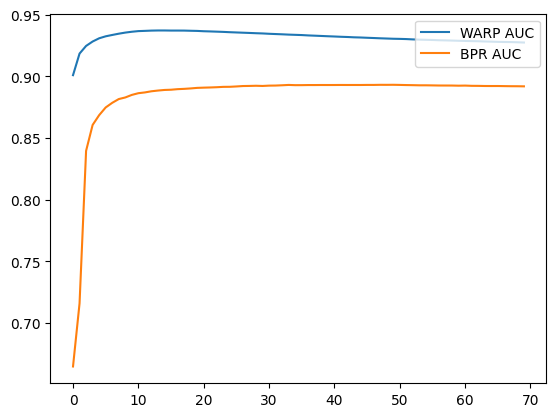

In [41]:
x = np.arange(epochs)
plt.plot(x, np.array(warp_auc))
plt.plot(x, np.array(bpr_auc))
plt.legend(['WARP AUC', 'BPR AUC'], loc='upper right')
plt.show()

### Fitting speed

What about model fitting speed?

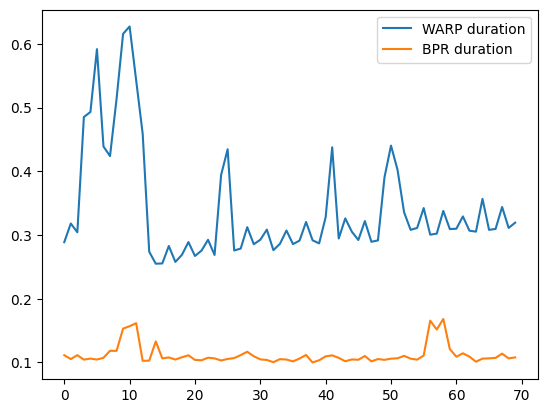

In [42]:
x = np.arange(epochs)
plt.plot(x, np.array(warp_duration))
plt.plot(x, np.array(bpr_duration))
plt.legend(['WARP duration', 'BPR duration'], loc='upper right')
plt.show()

WARP is slower than BPR for all epochs. Interestingly, however, it gets slower with additional epochs; every subsequent epoch takes more time. This is because of WARP's adaptive samling of negatives: the closer the model fits the training data, the more times it needs to sample in order to find rank-violating examples, leading to longer fitting times.

For this reason, LightFM exposes the `max_sampled` hyperparameter that limits the number of attemps WARP will carry out to find a negative. Setting it to a low value and repeating the run shows that the run time actually decreases with every epoch: this is because no updates happen when a violating example cannot be found in the specified number of attempts.

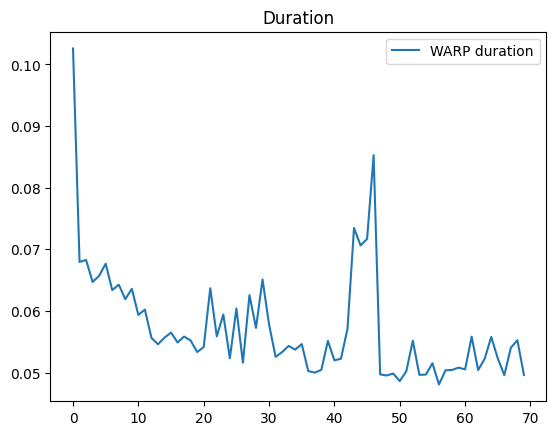

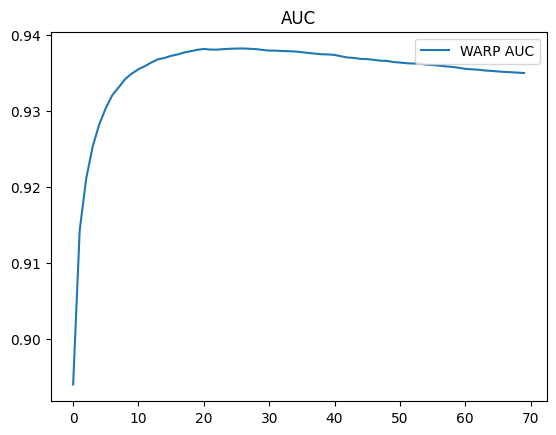

In [43]:
warp_model = LightFM(no_components=num_components,
                     max_sampled=3,
                    loss='warp',
                    learning_schedule='adagrad',
                    user_alpha=alpha,
                    item_alpha=alpha)
warp_duration = []
warp_auc = []

for epoch in range(epochs):
    start = time.time()
    warp_model.fit_partial(train, epochs=1)
    warp_duration.append(time.time() - start)
    warp_auc.append(auc_score(warp_model, test, train_interactions=train).mean())

x = np.arange(epochs)
plt.plot(x, np.array(warp_duration))
plt.legend(['WARP duration'], loc='upper right')
plt.title('Duration')
plt.show()

x = np.arange(epochs)
plt.plot(x, np.array(warp_auc))
plt.legend(['WARP AUC'], loc='upper right')
plt.title('AUC')
plt.show()

# End of Lab!

References:

[1] Surprise: A Python scikit for recommender systems (https://surpriselib.com/)

[2] Programming Collective Intelligence. Toby Segaran 2007.

[3] RecSys Lab @ Polimi

[4] LightFM: A Python implementation of popular recommendation algorithms for both implicit and explicit feedback (https://github.com/lyst/lightfm)